<a href="https://colab.research.google.com/github/Echinel/Echinel/blob/claude%2Fhel-churn-mitigation-framework-fZpOK/Northbridge_Healthcare_NHS_Trust_%E2%80%93_Pharmacy_%26_Medicines_Management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Impoorting Libraries and Loading Datatset**

In [5]:
import pandas as pd
import numpy as np
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

warnings.filterwarnings('ignore')

# Load datasets
hospital = pd.read_csv('Hospital.csv')
medicine = pd.read_csv('Medicine.csv')
hospital_activity = pd.read_csv('Hospital_Activity.csv')
medicine_demand = pd.read_csv('Medicine_Demand.csv')

# **Quick sanity checks before merging**

In [6]:
# %%
# ---- CELL 3: Quick sanity checks before merging ----
for name, df in [("Hospital", hospital), ("Medicine", medicine),
                  ("Hospital_Activity", hospital_activity),
                  ("Medicine_Demand", medicine_demand)]:
    print(f"\n--- {name} ---")
    print(df.info())
    print("Missing values:\n", df.isnull().sum())

# Confirm the panel is complete: hospitals x medicines x months
n_hospitals = medicine_demand["Hospital_ID"].nunique()
n_medicines = medicine_demand["Medicine_ID"].nunique()
n_months = medicine_demand["Date"].nunique()
print(f"\n{n_hospitals} hospitals x {n_medicines} medicines x {n_months} months "
      f"= {n_hospitals * n_medicines * n_months} expected rows "
      f"(actual: {len(medicine_demand)})")


--- Hospital ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Hospital_ID    8 non-null      object
 1   Hospital_Name  8 non-null      object
 2   Region         8 non-null      object
 3   Hospital_Type  8 non-null      object
 4   Beds           8 non-null      int64 
dtypes: int64(1), object(4)
memory usage: 452.0+ bytes
None
Missing values:
 Hospital_ID      0
Hospital_Name    0
Region           0
Hospital_Type    0
Beds             0
dtype: int64

--- Medicine ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Medicine_ID        45 non-null     object
 1   Medicine_Name      45 non-null     object
 2   Category           45 non-null     object
 3   Form               45 non-null     o

# **Merge into a single hospital-medicine-month panel**

In [7]:
# %%
# ---- CELL 4: Merge into a single hospital-medicine-month panel ----
# FR-1.1: merge all 4 sources keyed by hospital, medicine, month
df = medicine_demand.merge(medicine, on="Medicine_ID", how="left")
df = df.merge(hospital, on="Hospital_ID", how="left")
df = df.merge(hospital_activity, on=["Hospital_ID", "Date"], how="left")

# FR-1.2: check for any overlapping/duplicate columns after merge
print("Columns after merge:", df.columns.tolist())
print("Shape after merge:", df.shape)

# Sort for time-series operations later
df = df.sort_values(["Hospital_ID", "Medicine_ID", "Date"]).reset_index(drop=True)
df.head()

Columns after merge: ['Date', 'Hospital_ID', 'Medicine_ID', 'Quantity_Dispensed', 'Current_Stock', 'Unit_Cost', 'Emergency_Orders', 'Medicine_Waste', 'Medicine_Name', 'Category', 'Form', 'Shelf_Life_Months', 'Hospital_Name', 'Region', 'Hospital_Type', 'Beds', 'Admissions', 'Emergency_Admissions', 'Bed_Occupancy']
Shape after merge: (21600, 19)


,Date,Hospital_ID,Medicine_ID,Quantity_Dispensed,Current_Stock,Unit_Cost,Emergency_Orders,Medicine_Waste,Medicine_Name,Category,Form,Shelf_Life_Months,Hospital_Name,Region,Hospital_Type,Beds,Admissions,Emergency_Admissions,Bed_Occupancy
0,2021-01-01,H01,M001,2036,409,0.1495,0,0,Amoxicillin 500mg,Antibiotic,Capsule,24,Northbridge General Hospital,West Yorkshire,General,850,1360,544,78.1
1,2021-02-01,H01,M001,2252,986,0.1433,0,0,Amoxicillin 500mg,Antibiotic,Capsule,24,Northbridge General Hospital,West Yorkshire,General,850,1275,531,75.4
2,2021-03-01,H01,M001,2385,1840,0.1435,0,0,Amoxicillin 500mg,Antibiotic,Capsule,24,Northbridge General Hospital,West Yorkshire,General,850,1246,371,71.4
3,2021-04-01,H01,M001,1743,97,0.1554,0,0,Amoxicillin 500mg,Antibiotic,Capsule,24,Northbridge General Hospital,West Yorkshire,General,850,1197,490,72.5
4,2021-05-01,H01,M001,1494,2011,0.1482,0,0,Amoxicillin 500mg,Antibiotic,Capsule,24,Northbridge General Hospital,West Yorkshire,General,850,1078,369,68.1


# **Derived business fields (Section 6 of BRD)**

In [8]:
# %%
# ---- CELL 5: Derived business fields (Section 6 of BRD) ----
# Value_Dispensed
df["Value_Dispensed"] = df["Quantity_Dispensed"] * df["Unit_Cost"]

# Safety_Stock_Indicator: dispensed exceeded available stock -> stock-out risk flag
df["Safety_Stock_Indicator"] = (df["Quantity_Dispensed"] > df["Current_Stock"]).astype(int)

print("Safety_Stock_Indicator flagged rows:", df["Safety_Stock_Indicator"].sum())
print("Total Value_Dispensed (all years): £{:,.0f}".format(df["Value_Dispensed"].sum()))

Safety_Stock_Indicator flagged rows: 18378
Total Value_Dispensed (all years): £21,649,236


# **Cross-check Safety_Stock_Indicator vs raw Emergency_Orders column**

In [9]:
# %%
# ---- CELL 6: Cross-check Safety_Stock_Indicator vs raw Emergency_Orders column ----
# NOTE: Emergency_Orders exists in the raw file but is NOT part of the BRD's official
# data dictionary (Section 6). We use it here only as a validation check, not as the
# primary flag, since Safety_Stock_Indicator is what the BRD defines as the source of truth.
if "Emergency_Orders" in df.columns:
    crosstab = pd.crosstab(df["Safety_Stock_Indicator"],
                            df["Emergency_Orders"] > 0,
                            rownames=["Safety_Stock_Indicator"],
                            colnames=["Emergency_Orders>0"])
    print(crosstab)
    agreement_rate = (
        (df["Safety_Stock_Indicator"] == (df["Emergency_Orders"] > 0)).mean()
    )
    print(f"\nAgreement rate between the two signals: {agreement_rate:.1%}")

Emergency_Orders>0      False  True 
Safety_Stock_Indicator              
0                        3222      0
1                       14450   3928

Agreement rate between the two signals: 33.1%


# **Feature engineering (FR-1.5, FR-1.6)**

In [10]:
# %%
# ---- CELL 7: Feature engineering (FR-1.5, FR-1.6) ----
group_cols = ["Hospital_ID", "Medicine_ID"]

# Lagged demand & waste features (1, 2, 3 months)
for lag in [1, 2, 3]:
    df[f"Demand_Lag{lag}"] = df.groupby(group_cols)["Quantity_Dispensed"].shift(lag)
    df[f"Waste_Lag{lag}"] = df.groupby(group_cols)["Medicine_Waste"].shift(lag)

# Rolling 3-month average and volatility (std dev) of demand
# shift(1) first so the rolling window only uses PAST months (no look-ahead leakage)
df["Demand_RollingMean3"] = (
    df.groupby(group_cols)["Quantity_Dispensed"]
      .transform(lambda s: s.shift(1).rolling(window=3).mean())
)
df["Demand_RollingStd3"] = (
    df.groupby(group_cols)["Quantity_Dispensed"]
      .transform(lambda s: s.shift(1).rolling(window=3).std())
)

# Encode categorical attributes for later ML use (FR-1.6)
df_encoded = pd.get_dummies(
    df,
    columns=["Hospital_Type", "Category", "Form"],
    prefix=["HospType", "MedCat", "MedForm"]
)

print("New engineered columns:",
      [c for c in df.columns if "Lag" in c or "Rolling" in c])
df[group_cols + ["Date", "Quantity_Dispensed", "Demand_Lag1",
                 "Demand_RollingMean3", "Demand_RollingStd3"]].head(10)

New engineered columns: ['Demand_Lag1', 'Waste_Lag1', 'Demand_Lag2', 'Waste_Lag2', 'Demand_Lag3', 'Waste_Lag3', 'Demand_RollingMean3', 'Demand_RollingStd3']


,Hospital_ID,Medicine_ID,Date,Quantity_Dispensed,Demand_Lag1,Demand_RollingMean3,Demand_RollingStd3
0,H01,M001,2021-01-01,2036,NaN,NaN,NaN
1,H01,M001,2021-02-01,2252,2036.0,NaN,NaN
2,H01,M001,2021-03-01,2385,2252.0,NaN,NaN
3,H01,M001,2021-04-01,1743,2385.0,2224.333333,176.137257
4,H01,M001,2021-05-01,1494,1743.0,2126.666667,338.854443
5,H01,M001,2021-06-01,1079,1494.0,1874.000000,459.718392
6,H01,M001,2021-07-01,965,1079.0,1438.666667,335.440506
7,H01,M001,2021-08-01,875,965.0,1179.333333,278.406777
8,H01,M001,2021-09-01,930,875.0,973.000000,102.235023
9,H01,M001,2021-10-01,1307,930.0,923.333333,45.368859


# **Save the merged/engineered panel for use in modeling notebooks**

In [11]:
# %%
# ---- CELL 8: Save the merged/engineered panel for use in modeling notebooks ----
df.to_csv("panel_master.csv", index=False)
df_encoded.to_csv("panel_master_encoded.csv", index=False)
print("Saved panel_master.csv and panel_master_encoded.csv")
# In Colab, download or push these to Drive so 02/03/04 notebooks can reuse them:
# files.download("panel_master.csv")

Saved panel_master.csv and panel_master_encoded.csv


# **EDA SECTION**

---



# **Overall demand trend over time**



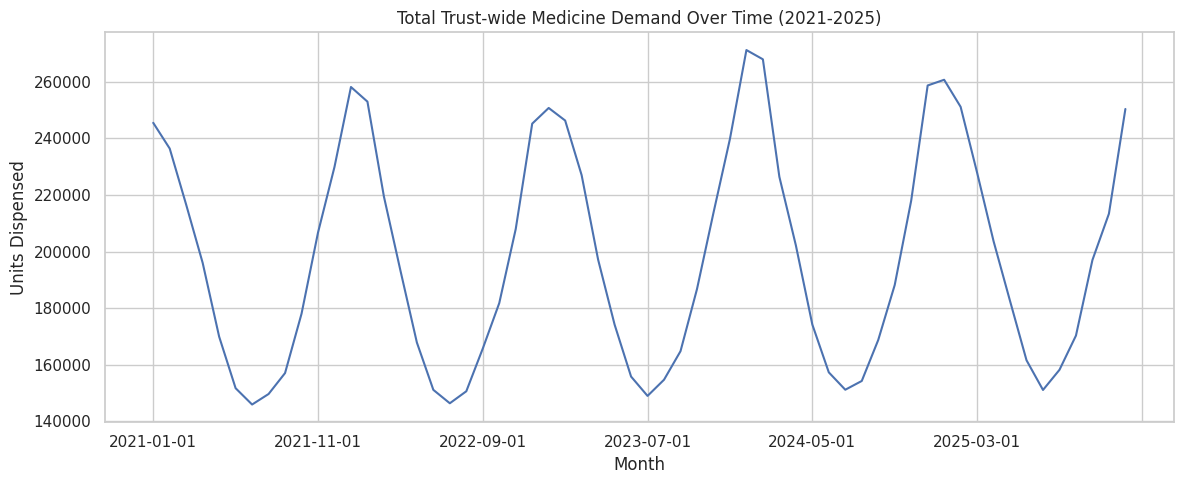

In [12]:
# %%
# ---- CELL 9: Overall demand trend over time ----
monthly_total = df.groupby("Date")["Quantity_Dispensed"].sum()

plt.figure(figsize=(12, 5))
monthly_total.plot()
plt.title("Total Trust-wide Medicine Demand Over Time (2021-2025)")
plt.ylabel("Units Dispensed")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

# **Seasonal decomposition (trend / seasonal / residual)**

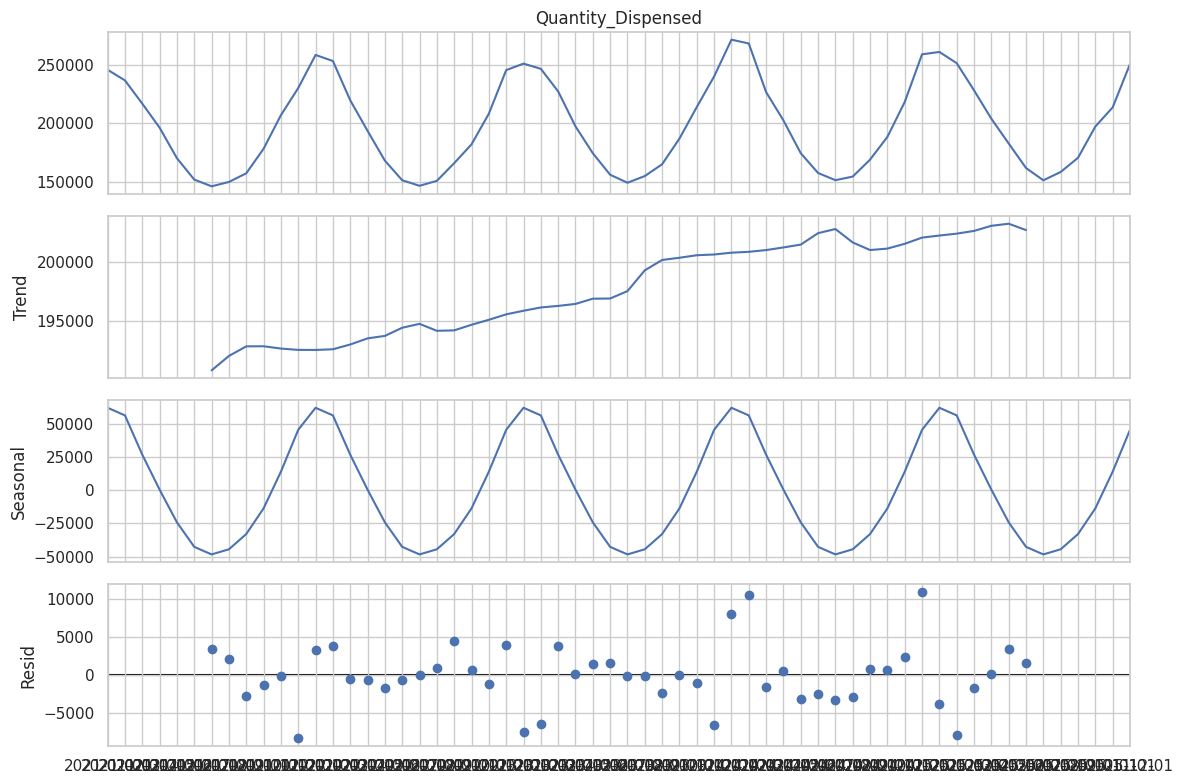

In [13]:
# %%
# ---- CELL 10: Seasonal decomposition (trend / seasonal / residual) ----
# Pick trust-wide total as an illustrative example; repeat per category if useful
decomposition = seasonal_decompose(monthly_total, model="additive", period=12)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

# **Demand trend by medicine Category**

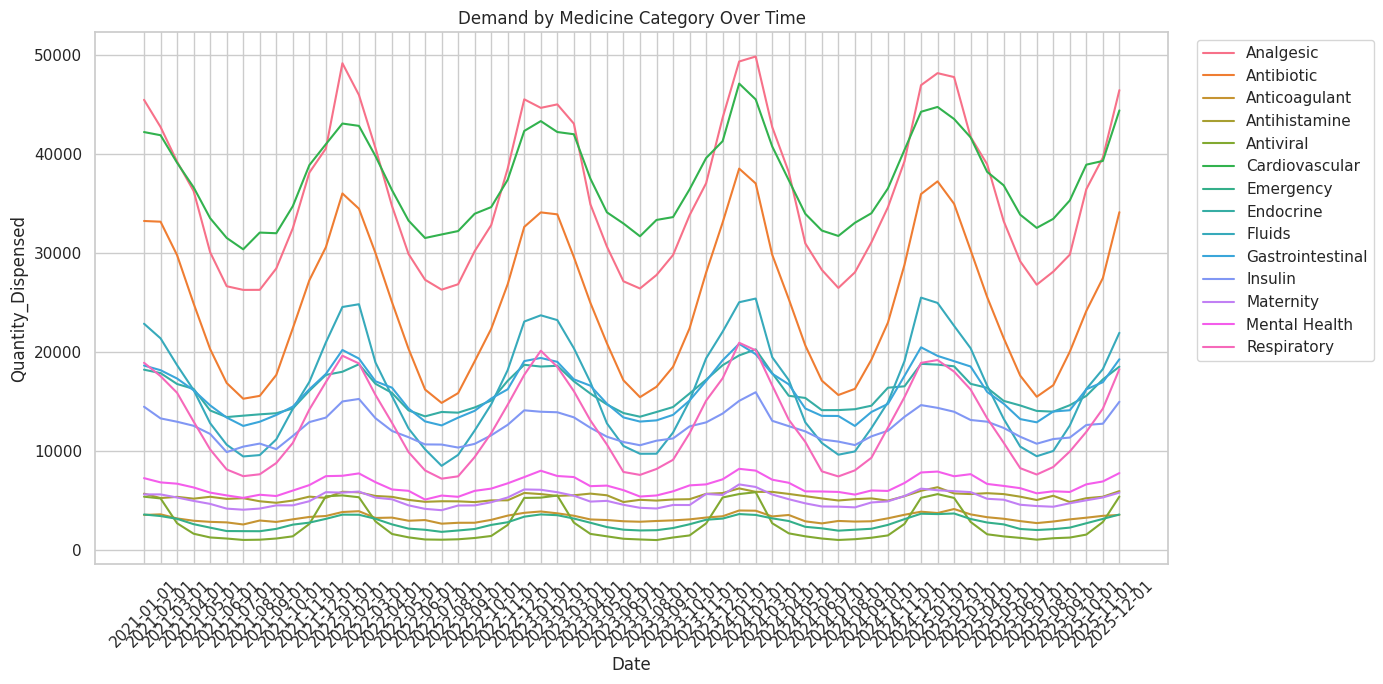

In [14]:
# %%
# ---- CELL 11: Demand trend by medicine Category ----
category_monthly = (
    df.groupby(["Date", "Category"])["Quantity_Dispensed"].sum().reset_index()
)

plt.figure(figsize=(14, 7))
sns.lineplot(data=category_monthly, x="Date", y="Quantity_Dispensed", hue="Category")
plt.title("Demand by Medicine Category Over Time")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# **ABC / XYZ classification**

In [15]:
# %%
# ---- CELL 12: ABC / XYZ classification ----
# ABC: value contribution (based on total Value_Dispensed)
# XYZ: demand variability (coefficient of variation of monthly Quantity_Dispensed)

medicine_value = (
    df.groupby("Medicine_ID")["Value_Dispensed"].sum()
      .sort_values(ascending=False)
)
medicine_value_pct = medicine_value / medicine_value.sum()
medicine_value_cum = medicine_value_pct.cumsum()

def abc_class(cum_pct):
    if cum_pct <= 0.80:
        return "A"
    elif cum_pct <= 0.95:
        return "B"
    else:
        return "C"

abc = medicine_value_cum.apply(abc_class)

# Coefficient of variation per medicine (aggregated across hospitals, monthly totals)
medicine_monthly = df.groupby(["Medicine_ID", "Date"])["Quantity_Dispensed"].sum().reset_index()
cv = (
    medicine_monthly.groupby("Medicine_ID")["Quantity_Dispensed"]
    .agg(lambda s: s.std() / s.mean())
)

def xyz_class(cv_val):
    if cv_val <= 0.5:
        return "X"
    elif cv_val <= 1.0:
        return "Y"
    else:
        return "Z"

xyz = cv.apply(xyz_class)

abc_xyz = pd.DataFrame({"ABC": abc, "XYZ": xyz}).join(medicine[["Medicine_ID", "Medicine_Name", "Category"]].set_index("Medicine_ID"))
abc_xyz["Segment"] = abc_xyz["ABC"] + abc_xyz["XYZ"]

print(abc_xyz["Segment"].value_counts())
abc_xyz.sort_values(["ABC", "XYZ"]).head(20)

Segment
CX    31
BX     7
AX     6
BZ     1
Name: count, dtype: int64


,ABC,XYZ,Medicine_Name,Category,Segment
Medicine_ID,,,,,
M008,A,X,Piperacillin-Tazobactam 4.5g,Antibiotic,AX
M015,A,X,Insulin Glargine 100u/ml,Insulin,AX
M016,A,X,Insulin Aspart 100u/ml,Insulin,AX
M017,A,X,Insulin Isophane (NPH),Insulin,AX
M022,A,X,Salbutamol Inhaler 100mcg,Respiratory,AX
M023,A,X,Beclometasone Inhaler,Respiratory,AX
M007,B,X,Vancomycin 1g Injection,Antibiotic,BX
M012,B,X,Morphine Sulfate 10mg Inj,Analgesic,BX
M031,B,X,Apixaban 5mg,Cardiovascular,BX


# **ABC/XYZ matrix heatmap (medicine counts per segment)**

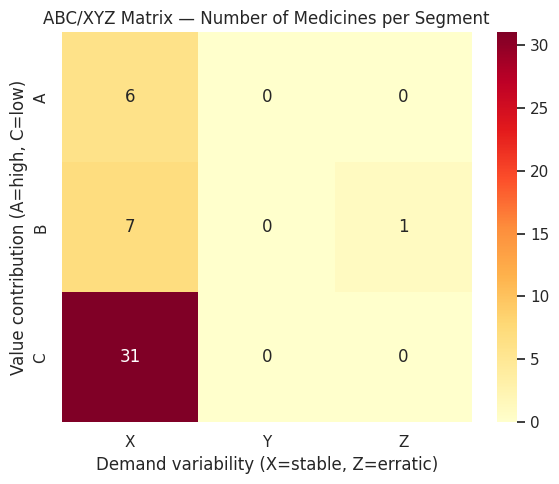

In [18]:
# %%# ---- CELL 13: ABC/XYZ matrix heatmap (medicine counts per segment) ----
segment_counts = abc_xyz.groupby(["ABC", "XYZ"]).size().unstack(fill_value=0)
segment_counts = segment_counts.reindex(index=["A", "B", "C"], columns=["X", "Y", "Z"])

# Convert segment_counts to integer type after filling any NaNs introduced by reindex
segment_counts = segment_counts.fillna(0).astype(int)

plt.figure(figsize=(6, 5))
sns.heatmap(segment_counts, annot=True, fmt="d", cmap="YlOrRd")
plt.title("ABC/XYZ Matrix — Number of Medicines per Segment")
plt.ylabel("Value contribution (A=high, C=low)")
plt.xlabel("Demand variability (X=stable, Z=erratic)")
plt.tight_layout()
plt.show()

# **Stock-out risk analysis (Safety_Stock_Indicator)**

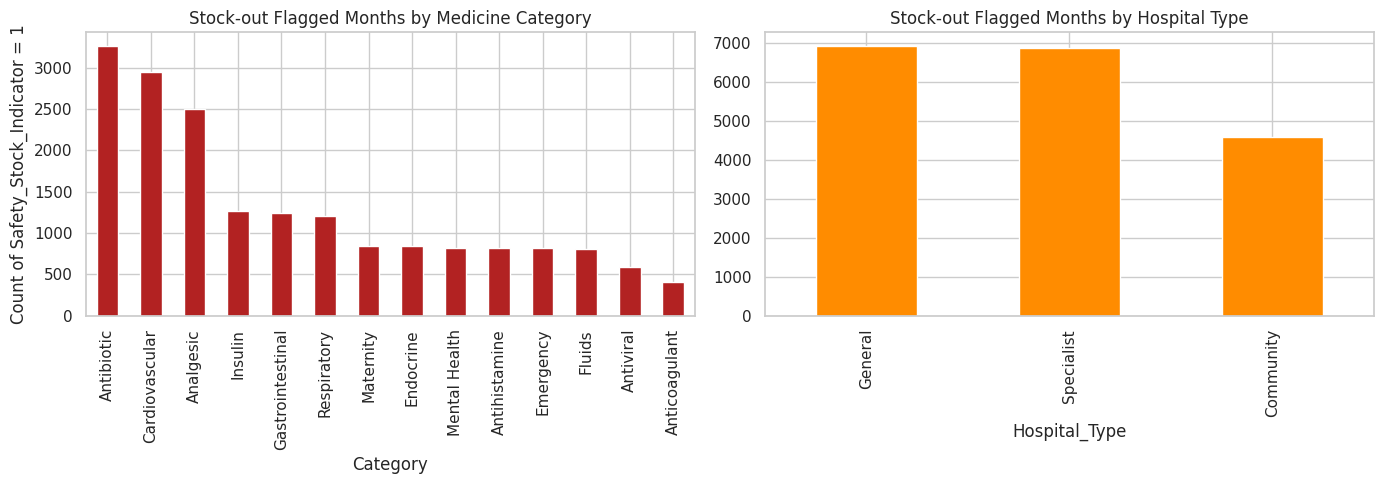

Total value dispensed during flagged stock-out months: £19,146,632


In [19]:
# %%
# ---- CELL 14: Stock-out risk analysis (Safety_Stock_Indicator) ----
stockout_by_category = (
    df.groupby("Category")["Safety_Stock_Indicator"].sum().sort_values(ascending=False)
)
stockout_by_hosptype = (
    df.groupby("Hospital_Type")["Safety_Stock_Indicator"].sum().sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
stockout_by_category.plot(kind="bar", ax=axes[0], color="firebrick")
axes[0].set_title("Stock-out Flagged Months by Medicine Category")
axes[0].set_ylabel("Count of Safety_Stock_Indicator = 1")

stockout_by_hosptype.plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Stock-out Flagged Months by Hospital Type")
plt.tight_layout()
plt.show()

# Estimated £ exposure of stock-out months (value that could not be dispensed on time)
stockout_value = df.loc[df["Safety_Stock_Indicator"] == 1, "Value_Dispensed"].sum()
print(f"Total value dispensed during flagged stock-out months: £{stockout_value:,.0f}")

# **Medicine waste analysis**

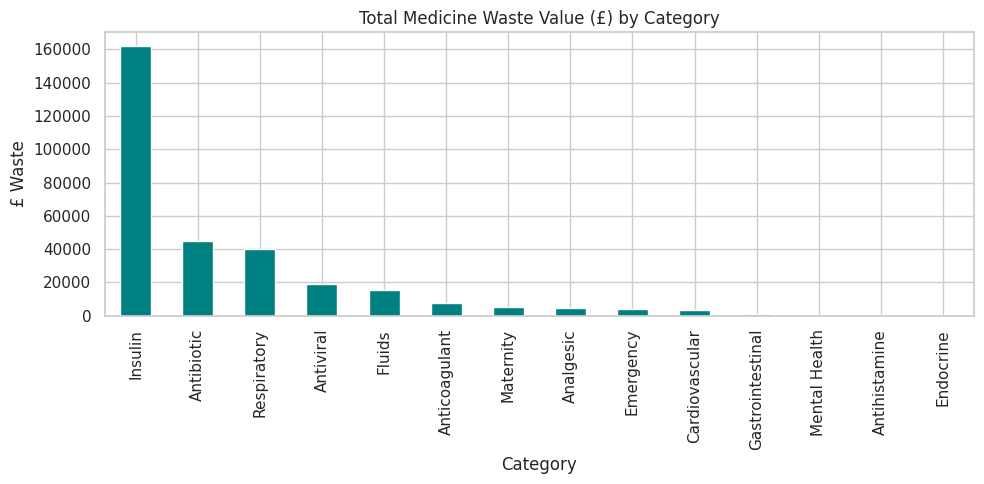

Total waste value across Trust (2021-2025): £308,678


In [20]:
# %%
# ---- CELL 15: Medicine waste analysis ----
df["Waste_Value"] = df["Medicine_Waste"] * df["Unit_Cost"]

waste_by_category = df.groupby("Category")["Waste_Value"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
waste_by_category.plot(kind="bar", color="teal")
plt.title("Total Medicine Waste Value (£) by Category")
plt.ylabel("£ Waste")
plt.tight_layout()
plt.show()

print(f"Total waste value across Trust (2021-2025): £{df['Waste_Value'].sum():,.0f}")

# **Emergency admissions vs demand correlation**

                      Total_Demand  Admissions  Emergency_Admissions  \
Total_Demand              1.000000    0.997463              0.984391   
Admissions                0.997463    1.000000              0.987269   
Emergency_Admissions      0.984391    0.987269              1.000000   
Bed_Occupancy             0.117978    0.097418              0.096058   

                      Bed_Occupancy  
Total_Demand               0.117978  
Admissions                 0.097418  
Emergency_Admissions       0.096058  
Bed_Occupancy              1.000000  


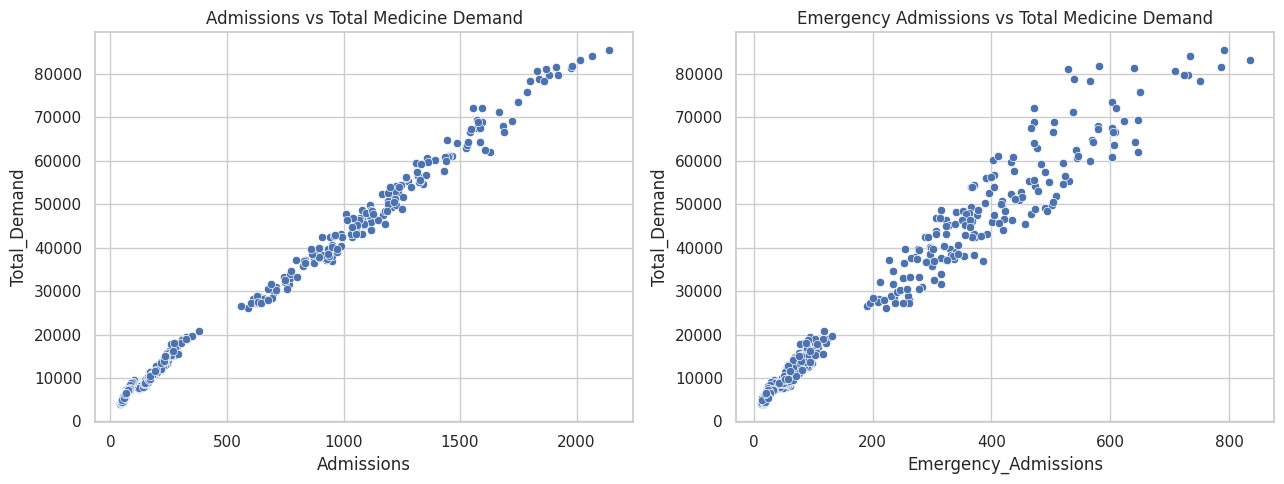

In [21]:
# %%
# ---- CELL 16: Emergency admissions vs demand correlation ----
# Sanity check the assumption in BRD Section 9.1 that admissions are a reasonable
# demand-driver proxy
corr_df = df.groupby(["Hospital_ID", "Date"]).agg(
    Total_Demand=("Quantity_Dispensed", "sum"),
    Admissions=("Admissions", "first"),
    Emergency_Admissions=("Emergency_Admissions", "first"),
    Bed_Occupancy=("Bed_Occupancy", "first"),
).reset_index()

print(corr_df[["Total_Demand", "Admissions", "Emergency_Admissions", "Bed_Occupancy"]].corr())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=corr_df, x="Admissions", y="Total_Demand", ax=axes[0])
axes[0].set_title("Admissions vs Total Medicine Demand")

sns.scatterplot(data=corr_df, x="Emergency_Admissions", y="Total_Demand", ax=axes[1])
axes[1].set_title("Emergency Admissions vs Total Medicine Demand")
plt.tight_layout()
plt.show()


# **Cost of current inefficiency — headline summary for stakeholders**

In [22]:

# %%
# ---- CELL 17: Cost of current inefficiency — headline summary for stakeholders ----
summary = {
    "Total medicines tracked": df["Medicine_ID"].nunique(),
    "Total hospitals": df["Hospital_ID"].nunique(),
    "Stock-out flagged months (Safety_Stock_Indicator)": int(df["Safety_Stock_Indicator"].sum()),
    "£ value dispensed during stock-out months": round(stockout_value, 0),
    "£ total medicine waste (2021-2025)": round(df["Waste_Value"].sum(), 0),
    "£ total value dispensed (2021-2025)": round(df["Value_Dispensed"].sum(), 0),
}
summary_df = pd.DataFrame.from_dict(summary, orient="index", columns=["Value"])
print(summary_df)


                                                        Value
Total medicines tracked                                  45.0
Total hospitals                                           8.0
Stock-out flagged months (Safety_Stock_Indicator)     18378.0
£ value dispensed during stock-out months          19146632.0
£ total medicine waste (2021-2025)                   308678.0
£ total value dispensed (2021-2025)                21649236.0


# **Detailed Inefficiency Analysis by Hospital and Category**


Total value dispensed during stock-out months per Hospital:
  Hospital_Type  Value_Dispensed
0       General       14470061.0
1    Specialist        3492347.0
2     Community        1184224.0


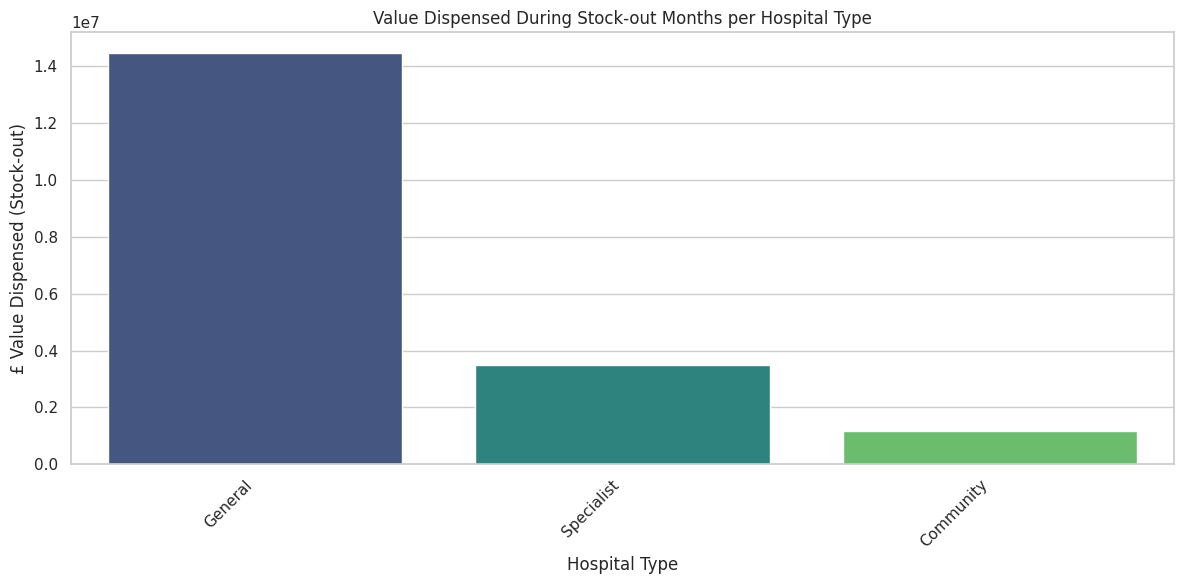

In [27]:
# Calculate stock-out value per hospital and hospital type
stockout_value_per_hospital = (
    df.loc[df["Safety_Stock_Indicator"] == 1]
    .groupby(["Hospital_Type"])["Value_Dispensed"]
    .sum()
    .round(0) # Round to 0 decimal places
    .sort_values(ascending=False)
    .reset_index()
)

print("\nTotal value dispensed during stock-out months per Hospital:")
print(stockout_value_per_hospital)

# Plotting stock-out value per hospital
plt.figure(figsize=(12, 6))
sns.barplot(data=stockout_value_per_hospital, x='Hospital_Type', y='Value_Dispensed', hue='Hospital_Type', palette='viridis')
plt.title('Value Dispensed During Stock-out Months per Hospital Type')
plt.xlabel('Hospital Type')
plt.ylabel('£ Value Dispensed (Stock-out)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Total medicine waste per Hospital Type:
  Hospital_Type  Waste_Value
0       General     234184.0
1    Specialist      56105.0
2     Community      18389.0


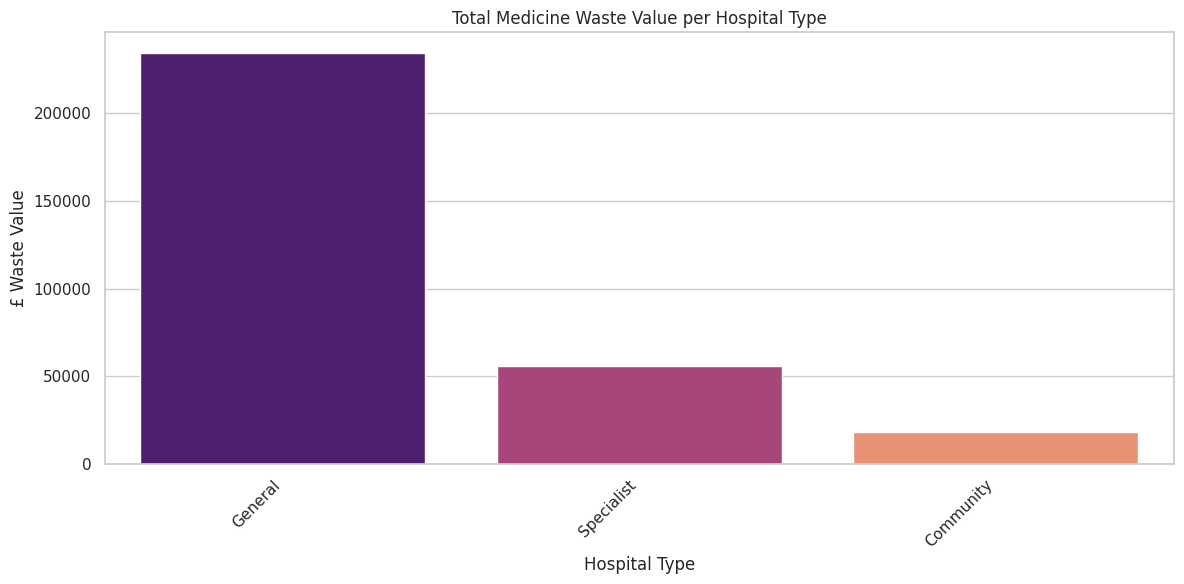

In [28]:
# Calculate total medicine waste per hospital type
waste_value_per_hospital_type = (
    df.groupby(["Hospital_Type"])["Waste_Value"]
    .sum()
    .round(0) # Round to 0 decimal places
    .sort_values(ascending=False)
    .reset_index()
)

print("\nTotal medicine waste per Hospital Type:")
print(waste_value_per_hospital_type)

# Plotting waste value per hospital type
plt.figure(figsize=(12, 6))
sns.barplot(data=waste_value_per_hospital_type, x='Hospital_Type', y='Waste_Value', hue='Hospital_Type', palette='magma')
plt.title('Total Medicine Waste Value per Hospital Type')
plt.xlabel('Hospital Type')
plt.ylabel('£ Waste Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **END OF NOTEBOOK 1**

---



# **SARIMAX Model (per Hospital-Medicine pair, per FR-2.1)**

# **Setup & Imports**

In [30]:
# ---- CELL 1: Setup & Imports ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")  # SARIMAX convergence warnings get noisy across 360 fits
pd.set_option("display.max_columns", None)

# **Load merged panel**

In [31]:
# %%
# ---- CELL 2: Load merged panel ----
from google.colab import files
uploaded = files.upload()  # select panel_master.csv

df = pd.read_csv("panel_master.csv", parse_dates=["Date"])
df = df.sort_values(["Hospital_ID", "Medicine_ID", "Date"]).reset_index(drop=True)
print(df.shape)
df.head()

Saving panel_master.csv to panel_master (1).csv
(21600, 29)


,Date,Hospital_ID,Medicine_ID,Quantity_Dispensed,Current_Stock,Unit_Cost,Emergency_Orders,Medicine_Waste,Medicine_Name,Category,Form,Shelf_Life_Months,Hospital_Name,Region,Hospital_Type,Beds,Admissions,Emergency_Admissions,Bed_Occupancy,Value_Dispensed,Safety_Stock_Indicator,Demand_Lag1,Waste_Lag1,Demand_Lag2,Waste_Lag2,Demand_Lag3,Waste_Lag3,Demand_RollingMean3,Demand_RollingStd3
0,2021-01-01,H01,M001,2036,409,0.1495,0,0,Amoxicillin 500mg,Antibiotic,Capsule,24,Northbridge General Hospital,West Yorkshire,General,850,1360,544,78.1,304.3820,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-02-01,H01,M001,2252,986,0.1433,0,0,Amoxicillin 500mg,Antibiotic,Capsule,24,Northbridge General Hospital,West Yorkshire,General,850,1275,531,75.4,322.7116,1,2036.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-03-01,H01,M001,2385,1840,0.1435,0,0,Amoxicillin 500mg,Antibiotic,Capsule,24,Northbridge General Hospital,West Yorkshire,General,850,1246,371,71.4,342.2475,1,2252.0,0.0,2036.0,0.0,NaN,NaN,NaN,NaN
3,2021-04-01,H01,M001,1743,97,0.1554,0,0,Amoxicillin 500mg,Antibiotic,Capsule,24,Northbridge General Hospital,West Yorkshire,General,850,1197,490,72.5,270.8622,1,2385.0,0.0,2252.0,0.0,2036.0,0.0,2224.333333,176.137257
4,2021-05-01,H01,M001,1494,2011,0.1482,0,0,Amoxicillin 500mg,Antibiotic,Capsule,24,Northbridge General Hospital,West Yorkshire,General,850,1078,369,68.1,221.4108,0,1743.0,0.0,2385.0,0.0,2252.0,0.0,2126.666667,338.854443


# **Train/test split — most recent 12 months held out (FR-2.3)**

In [32]:
# %%
# ---- CELL 3: Train/test split — most recent 12 months held out (FR-2.3) ----
cutoff_date = df["Date"].max() - pd.DateOffset(months=11)  # last 12 months = test
print("Test period starts:", cutoff_date.date())

train_mask = df["Date"] < cutoff_date
test_mask = df["Date"] >= cutoff_date

print("Train rows:", train_mask.sum(), " Test rows:", test_mask.sum())

Test period starts: 2025-01-01
Train rows: 17280  Test rows: 4320


# **Helper function — fit + forecast one Hospital-Medicine series**

In [36]:
# %%
# ---- CELL 4: Helper function — fit + forecast one Hospital-Medicine series ----
def fit_sarimax_for_pair(group, exog_cols=("Admissions", "Bed_Occupancy"),
                          order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)):
    """
    group: dataframe for a single Hospital_ID x Medicine_ID pair, sorted by Date,
           containing both train and test rows.
    Returns: dict with forecast values, actuals, and fitted model (or None on failure).
    """
    group = group.set_index("Date")
    y_train = group.loc[group.index < cutoff_date, "Quantity_Dispensed"]
    y_test = group.loc[group.index >= cutoff_date, "Quantity_Dispensed"]

    exog_train = group.loc[group.index < cutoff_date, list(exog_cols)]
    exog_test = group.loc[group.index >= cutoff_date, list(exog_cols)]

    if len(y_train) < 24:  # need at least 2 years of history for seasonal_order=12
        return None

    try:
        model = SARIMAX(
            y_train,
            exog=exog_train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        fitted = model.fit(disp=False)
        forecast = fitted.get_forecast(steps=len(y_test), exog=exog_test)
        y_pred = forecast.predicted_mean
        return {"y_test": y_test, "y_pred": y_pred, "model": fitted}
    except Exception as e:
        return {"error": str(e)}





# **Loop over all 360 Hospital-Medicine pairs**

In [37]:
# %%
# ---- CELL 5: Loop over all 360 Hospital-Medicine pairs ----
results = []
pairs = df[["Hospital_ID", "Medicine_ID"]].drop_duplicates().values

for hospital_id, medicine_id in pairs:
    group = df[(df["Hospital_ID"] == hospital_id) & (df["Medicine_ID"] == medicine_id)]
    result = fit_sarimax_for_pair(group)

    if result is None or "error" in result:
        results.append({
            "Hospital_ID": hospital_id, "Medicine_ID": medicine_id,
            "status": "failed", "MAE": np.nan, "RMSE": np.nan, "MAPE": np.nan
        })
        continue

    y_test, y_pred = result["y_test"], result["y_pred"]
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred) / y_test.replace(0, np.nan))) * 100

    results.append({
        "Hospital_ID": hospital_id, "Medicine_ID": medicine_id,
        "status": "ok", "MAE": mae, "RMSE": rmse, "MAPE": mape
    })

sarimax_results = pd.DataFrame(results)
print("Fitted successfully:", (sarimax_results["status"] == "ok").sum(), "/", len(sarimax_results))
sarimax_results.head()

Fitted successfully: 360 / 360


,Hospital_ID,Medicine_ID,status,MAE,RMSE,MAPE
0,H01,M001,ok,202.355647,292.690990,12.168725
1,H01,M002,ok,126.429902,175.229294,8.979736
2,H01,M003,ok,103.545436,138.074937,12.095542
3,H01,M004,ok,62.416774,79.119608,9.648636
4,H01,M005,ok,49.939089,61.602566,8.888995


# **Save per-pair forecasts (needed later for the replenishment ledger)**

In [38]:
# %%
# ---- CELL 6: Save per-pair forecasts (needed later for the replenishment ledger) ----
# Re-run the loop but this time keep the actual forecast values, not just metrics.
# Kept as a separate cell so Cell 5 (metrics-only) runs fast first; re-use if you want
# the full forecast table.

forecast_rows = []
for hospital_id, medicine_id in pairs:
    group = df[(df["Hospital_ID"] == hospital_id) & (df["Medicine_ID"] == medicine_id)]
    result = fit_sarimax_for_pair(group)
    if result is None or "error" in result:
        continue
    y_test, y_pred = result["y_test"], result["y_pred"]
    temp = pd.DataFrame({
        "Hospital_ID": hospital_id,
        "Medicine_ID": medicine_id,
        "Date": y_test.index,
        "Actual_Demand": y_test.values,
        "SARIMAX_Forecast": y_pred.values,
    })
    forecast_rows.append(temp)

sarimax_forecasts = pd.concat(forecast_rows, ignore_index=True)
sarimax_forecasts.to_csv("sarimax_forecasts.csv", index=False)
print(sarimax_forecasts.shape)
sarimax_forecasts.head()

(4320, 5)


,Hospital_ID,Medicine_ID,Date,Actual_Demand,SARIMAX_Forecast
0,H01,M001,2025-01-01,3075,2389.104311
1,H01,M001,2025-02-01,2257,2219.880834
2,H01,M001,2025-03-01,1822,2290.574310
3,H01,M001,2025-04-01,1437,1460.206578
4,H01,M001,2025-05-01,1231,1554.660294


# **Overall SARIMAX performance summary**

In [39]:
# %%
# ---- CELL 7: Overall SARIMAX performance summary ----
overall_mae = mean_absolute_error(sarimax_forecasts["Actual_Demand"], sarimax_forecasts["SARIMAX_Forecast"])
overall_rmse = np.sqrt(mean_squared_error(sarimax_forecasts["Actual_Demand"], sarimax_forecasts["SARIMAX_Forecast"]))
overall_mape = np.mean(
    np.abs((sarimax_forecasts["Actual_Demand"] - sarimax_forecasts["SARIMAX_Forecast"])
           / sarimax_forecasts["Actual_Demand"].replace(0, np.nan))
) * 100

# Bias: positive = systematically under-forecasting (risk of stockouts),
#       negative = systematically over-forecasting (risk of waste)
bias = (sarimax_forecasts["Actual_Demand"] - sarimax_forecasts["SARIMAX_Forecast"]).mean()

print(f"SARIMAX overall — MAE: {overall_mae:.2f}, RMSE: {overall_rmse:.2f}, "
      f"MAPE: {overall_mape:.1f}%, Bias: {bias:+.2f} units/month")

# %%
# ---- CELL 8: Performance by medicine Category (join back to Medicine.csv) ----
medicine = pd.read_csv("Medicine.csv")  # re-upload if not already in this session
sarimax_by_cat = sarimax_forecasts.merge(medicine[["Medicine_ID", "Category"]], on="Medicine_ID")

cat_perf = sarimax_by_cat.groupby("Category").apply(
    lambda g: pd.Series({
        "MAE": mean_absolute_error(g["Actual_Demand"], g["SARIMAX_Forecast"]),
        "MAPE": np.mean(np.abs((g["Actual_Demand"] - g["SARIMAX_Forecast"])
                                / g["Actual_Demand"].replace(0, np.nan))) * 100
    })
).sort_values("MAPE")

print(cat_perf)

SARIMAX overall — MAE: 59.73, RMSE: 114.60, MAPE: 11.2%, Bias: -1.34 units/month
                         MAE       MAPE
Category                               
Mental Health      33.789741   9.219010
Insulin            53.418178   9.908374
Fluids            104.778885  10.246324
Cardiovascular     69.179022  10.481837
Maternity          30.941159  10.714628
Emergency          17.279005  10.738716
Anticoagulant      38.599887  10.779138
Antihistamine      36.459507  10.795416
Endocrine         104.491707  11.076712
Gastrointestinal   78.839718  11.488526
Antibiotic         46.037991  11.501240
Analgesic          83.635972  11.811359
Respiratory        66.697954  11.978571
Antiviral          21.283795  16.182337


# **Visual — actual vs forecast for a sample series**


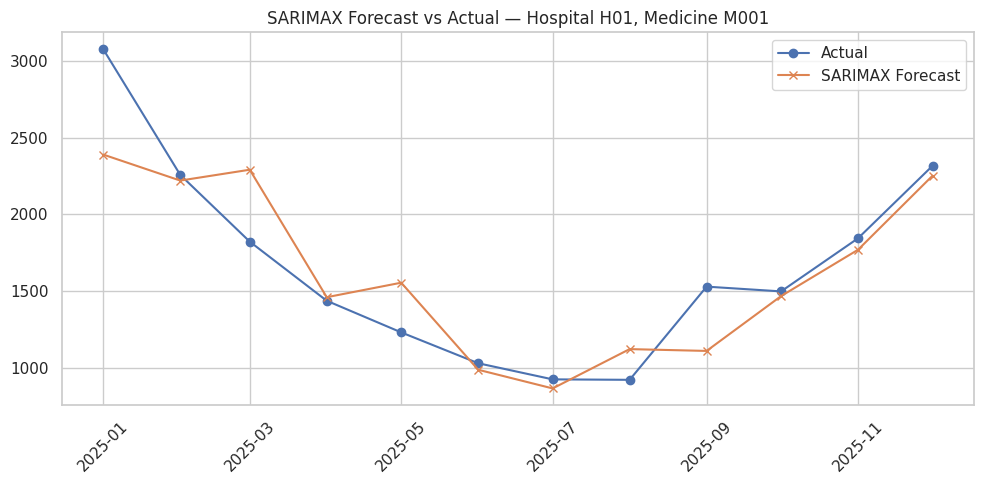

In [40]:
# %%
# ---- CELL 9: Visual — actual vs forecast for a sample series ----
sample = sarimax_forecasts[
    (sarimax_forecasts["Hospital_ID"] == pairs[0][0]) &
    (sarimax_forecasts["Medicine_ID"] == pairs[0][1])
]

plt.figure(figsize=(10, 5))
plt.plot(sample["Date"], sample["Actual_Demand"], label="Actual", marker="o")
plt.plot(sample["Date"], sample["SARIMAX_Forecast"], label="SARIMAX Forecast", marker="x")
plt.title(f"SARIMAX Forecast vs Actual — Hospital {pairs[0][0]}, Medicine {pairs[0][1]}")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **END OF NOTBOOK 2**

---



# **XGBoost Model — single global model across all series (FR-2.2)**

# **Setup & Imports**

In [41]:
# %%
# ---- CELL 1: Setup & Imports ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", None)

# **Load engineered/encoded panel**

In [42]:
# %%
# ---- CELL 2: Load engineered/encoded panel ----
from google.colab import files
uploaded = files.upload()  # select panel_master_encoded.csv

df = pd.read_csv("panel_master_encoded.csv", parse_dates=["Date"])
df = df.sort_values(["Hospital_ID", "Medicine_ID", "Date"]).reset_index(drop=True)
print(df.shape)

Saving panel_master_encoded.csv to panel_master_encoded (1).csv
(21600, 47)


# **Drop rows without full lag history**

In [43]:
# %%
# ---- CELL 3: Drop rows without full lag history ----
# Rows in the first 3 months of each series won't have Demand_Lag1-3 populated —
# XGBoost can't use these for training, so we drop them (SARIMAX doesn't have this
# issue since it models the series natively).
feature_cols = [
    "Demand_Lag1", "Demand_Lag2", "Demand_Lag3",
    "Waste_Lag1", "Waste_Lag2", "Waste_Lag3",
    "Demand_RollingMean3", "Demand_RollingStd3",
    "Admissions", "Emergency_Admissions", "Bed_Occupancy",
]
# Add the one-hot encoded categorical columns created in Notebook 1
encoded_cols = [c for c in df.columns if c.startswith(("HospType_", "MedCat_", "MedForm_"))]
feature_cols += encoded_cols

# Add month as a feature to capture seasonality
df["Month"] = df["Date"].dt.month
feature_cols.append("Month")

model_df = df.dropna(subset=feature_cols + ["Quantity_Dispensed"]).copy()
print(f"Rows before dropna: {len(df)}, after: {len(model_df)}")

Rows before dropna: 21600, after: 20520


# **Train/test split — same 12-month holdout as SARIMAX (FR-2.3)**

In [44]:
# %%
# ---- CELL 4: Train/test split — same 12-month holdout as SARIMAX (FR-2.3) ----
cutoff_date = model_df["Date"].max() - pd.DateOffset(months=11)

train = model_df[model_df["Date"] < cutoff_date]
test = model_df[model_df["Date"] >= cutoff_date]

X_train, y_train = train[feature_cols], train["Quantity_Dispensed"]
X_test, y_test = test[feature_cols], test["Quantity_Dispensed"]

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (16200, 33)  Test shape: (4320, 33)


# **Fit the global XGBoost model**

In [45]:
# %%
# ---- CELL 5: Fit the global XGBoost model ----
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror",
)

xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)
y_pred = np.clip(y_pred, 0, None)  # demand can't be negative

# %%
# ---- CELL 6: Overall performance metrics ----
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test.replace(0, np.nan))) * 100
bias = (y_test - y_pred).mean()

print(f"XGBoost overall — MAE: {mae:.2f}, RMSE: {rmse:.2f}, "
      f"MAPE: {mape:.1f}%, Bias: {bias:+.2f} units/month")

XGBoost overall — MAE: 60.18, RMSE: 115.62, MAPE: 12.3%, Bias: -4.25 units/month


# **Save forecasts for the comparison notebook**

In [46]:
# %%
# ---- CELL 7: Save forecasts for the comparison notebook ----
xgb_forecasts = test[["Hospital_ID", "Medicine_ID", "Date"]].copy()
xgb_forecasts["Actual_Demand"] = y_test.values
xgb_forecasts["XGBoost_Forecast"] = y_pred
xgb_forecasts.to_csv("xgboost_forecasts.csv", index=False)
xgb_forecasts.head()

,Hospital_ID,Medicine_ID,Date,Actual_Demand,XGBoost_Forecast
48,H01,M001,2025-01-01,3075,2279.652344
49,H01,M001,2025-02-01,2257,2550.385010
50,H01,M001,2025-03-01,1822,2170.487549
51,H01,M001,2025-04-01,1437,1398.738892
52,H01,M001,2025-05-01,1231,1286.491333


# **Performance by medicine Category**

In [48]:
# %%# ---- CELL 8: Performance by medicine Category ----
xgb_by_cat = xgb_forecasts.merge(
    medicine[["Medicine_ID", "Category"]].drop_duplicates(), on="Medicine_ID"
)
cat_perf = xgb_by_cat.groupby("Category").apply(
    lambda g: pd.Series({
        "MAE": mean_absolute_error(g["Actual_Demand"], g["XGBoost_Forecast"]),
        "MAPE": np.mean(np.abs((g["Actual_Demand"] - g["XGBoost_Forecast"])
                                / g["Actual_Demand"].replace(0, np.nan))) * 100
    })
).sort_values("MAPE")
print(cat_perf)

                         MAE       MAPE
Category                               
Cardiovascular     62.529060   9.836095
Insulin            57.460300  10.355758
Fluids            110.927574  10.489453
Maternity          31.103647  10.655152
Mental Health      39.961174  10.694006
Analgesic          79.973274  10.974998
Endocrine         107.922180  10.977125
Respiratory        61.223389  11.009817
Gastrointestinal   74.246742  11.171530
Anticoagulant      44.045227  11.200078
Antibiotic         47.253193  12.437911
Emergency          18.488001  13.209429
Antihistamine      55.861126  16.998399
Antiviral          30.595922  32.778463


# **Feature importance**

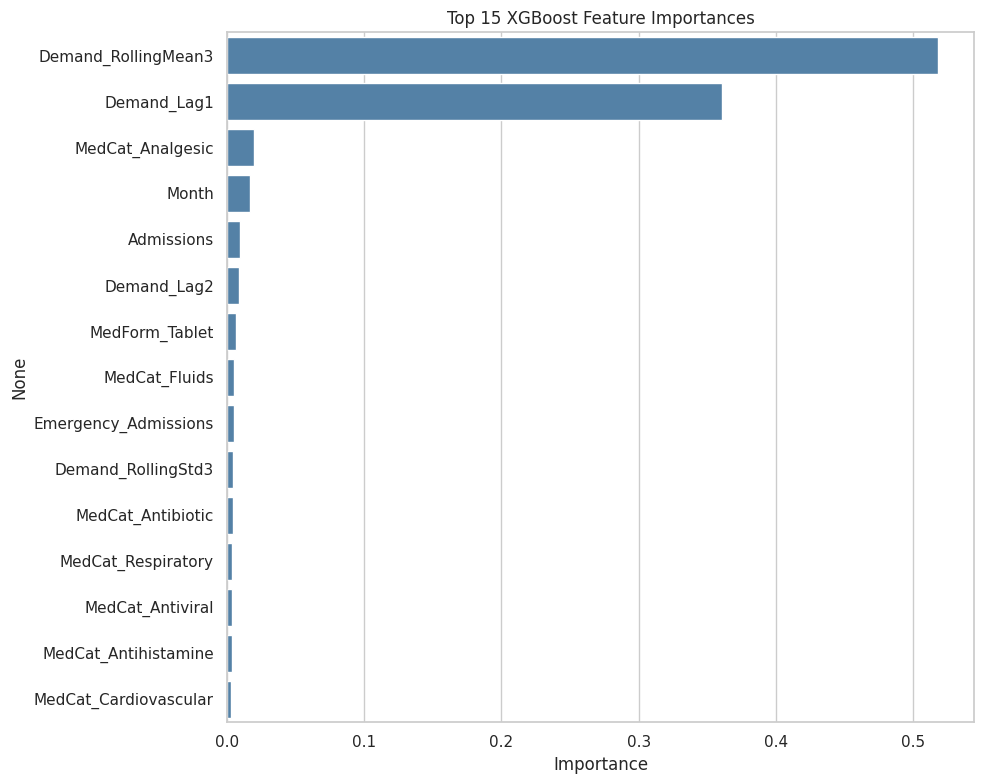

In [49]:
# %%
# ---- CELL 9: Feature importance ----
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index, color="steelblue")
plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


# **Visual — actual vs forecast for a sample series**

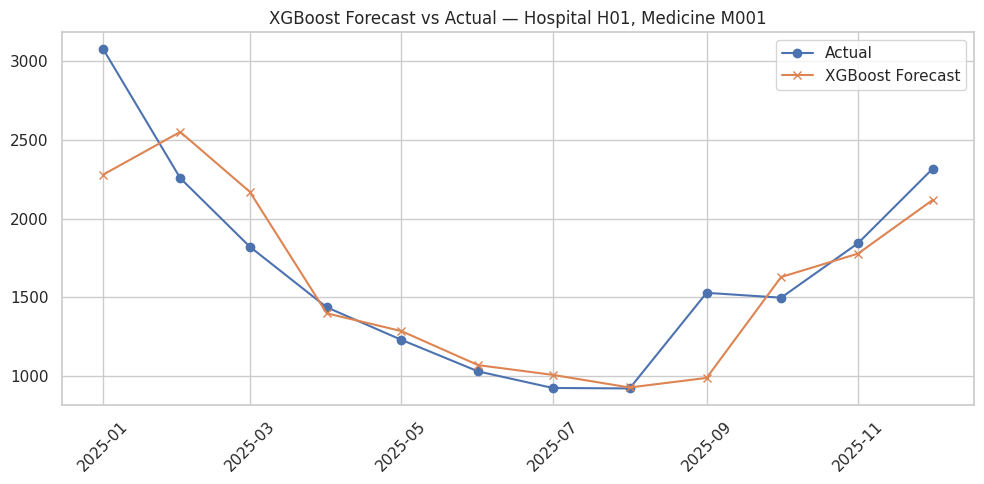

In [50]:
# %%
# ---- CELL 10: Visual — actual vs forecast for a sample series ----
sample_hosp = xgb_forecasts["Hospital_ID"].iloc[0]
sample_med = xgb_forecasts["Medicine_ID"].iloc[0]
sample = xgb_forecasts[
    (xgb_forecasts["Hospital_ID"] == sample_hosp) &
    (xgb_forecasts["Medicine_ID"] == sample_med)
]

plt.figure(figsize=(10, 5))
plt.plot(sample["Date"], sample["Actual_Demand"], label="Actual", marker="o")
plt.plot(sample["Date"], sample["XGBoost_Forecast"], label="XGBoost Forecast", marker="x")
plt.title(f"XGBoost Forecast vs Actual — Hospital {sample_hosp}, Medicine {sample_med}")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **END OF NOTEBOOK 3**

---



# **Model Comparison — XGBoost benchmarked against SARIMAX baseline**



# **Setup & Imports**

In [51]:
# %%
# ---- CELL 1: Setup & Imports ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# %%
# ---- CELL 2: Load both forecast outputs ----
from google.colab import files
uploaded = files.upload()  # select sarimax_forecasts.csv AND xgboost_forecasts.csv

sarimax_fc = pd.read_csv("sarimax_forecasts.csv", parse_dates=["Date"])
xgb_fc = pd.read_csv("xgboost_forecasts.csv", parse_dates=["Date"])

Saving xgboost_forecasts.csv to xgboost_forecasts (1).csv
Saving sarimax_forecasts.csv to sarimax_forecasts (1).csv


# **Merge on the common key so we compare like-for-like rows**

In [52]:
# %%
# ---- CELL 3: Merge on the common key so we compare like-for-like rows ----
comparison = sarimax_fc.merge(
    xgb_fc[["Hospital_ID", "Medicine_ID", "Date", "XGBoost_Forecast"]],
    on=["Hospital_ID", "Medicine_ID", "Date"],
    how="inner"  # only rows both models produced a forecast for
)
print("Rows compared:", len(comparison))
comparison.head()

Rows compared: 4320


,Hospital_ID,Medicine_ID,Date,Actual_Demand,SARIMAX_Forecast,XGBoost_Forecast
0,H01,M001,2025-01-01,3075,2389.104311,2279.6523
1,H01,M001,2025-02-01,2257,2219.880834,2550.3850
2,H01,M001,2025-03-01,1822,2290.574310,2170.4875
3,H01,M001,2025-04-01,1437,1460.206578,1398.7389
4,H01,M001,2025-05-01,1231,1554.660294,1286.4913


# **Overall metric comparison table**

In [53]:
# %%
# ---- CELL 4: Overall metric comparison table ----
def metrics(actual, pred):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / actual.replace(0, np.nan))) * 100
    bias = (actual - pred).mean()
    return pd.Series({"MAE": mae, "RMSE": rmse, "MAPE": mape, "Bias": bias})

results_table = pd.DataFrame({
    "SARIMAX (baseline)": metrics(comparison["Actual_Demand"], comparison["SARIMAX_Forecast"]),
    "XGBoost": metrics(comparison["Actual_Demand"], comparison["XGBoost_Forecast"]),
})
results_table["Improvement_%"] = (
    (results_table["SARIMAX (baseline)"] - results_table["XGBoost"])
    / results_table["SARIMAX (baseline)"] * 100
)
print(results_table)

      SARIMAX (baseline)     XGBoost  Improvement_%
MAE            59.730843   60.180541      -0.752874
RMSE          114.603584  115.623227      -0.889713
MAPE           11.224506   12.324920      -9.803671
Bias           -1.341844   -4.246594    -216.474473


# **Comparison by medicine Category — where does each model win?**

In [54]:
# %%
# ---- CELL 5: Comparison by medicine Category — where does each model win? ----
medicine = pd.read_csv("Medicine.csv")
comparison_cat = comparison.merge(medicine[["Medicine_ID", "Category"]], on="Medicine_ID")

def cat_metrics(g):
    sarimax_mape = np.mean(np.abs((g["Actual_Demand"] - g["SARIMAX_Forecast"])
                                   / g["Actual_Demand"].replace(0, np.nan))) * 100
    xgb_mape = np.mean(np.abs((g["Actual_Demand"] - g["XGBoost_Forecast"])
                               / g["Actual_Demand"].replace(0, np.nan))) * 100
    return pd.Series({"SARIMAX_MAPE": sarimax_mape, "XGBoost_MAPE": xgb_mape})

cat_comparison = comparison_cat.groupby("Category").apply(cat_metrics)
cat_comparison["Better_Model"] = np.where(
    cat_comparison["XGBoost_MAPE"] < cat_comparison["SARIMAX_MAPE"], "XGBoost", "SARIMAX"
)
print(cat_comparison.sort_values("Better_Model"))

                  SARIMAX_MAPE  XGBoost_MAPE Better_Model
Category                                                 
Antibiotic           11.501240     12.437911      SARIMAX
Anticoagulant        10.779138     11.200078      SARIMAX
Antihistamine        10.795416     16.998399      SARIMAX
Antiviral            16.182337     32.778463      SARIMAX
Emergency            10.738716     13.209430      SARIMAX
Fluids               10.246324     10.489453      SARIMAX
Insulin               9.908374     10.355758      SARIMAX
Mental Health         9.219010     10.694006      SARIMAX
Analgesic            11.811359     10.974997      XGBoost
Cardiovascular       10.481837      9.836095      XGBoost
Endocrine            11.076712     10.977125      XGBoost
Gastrointestinal     11.488526     11.171530      XGBoost
Maternity            10.714628     10.655152      XGBoost
Respiratory          11.978571     11.009817      XGBoost


# **Visual — side-by-side MAPE per category**

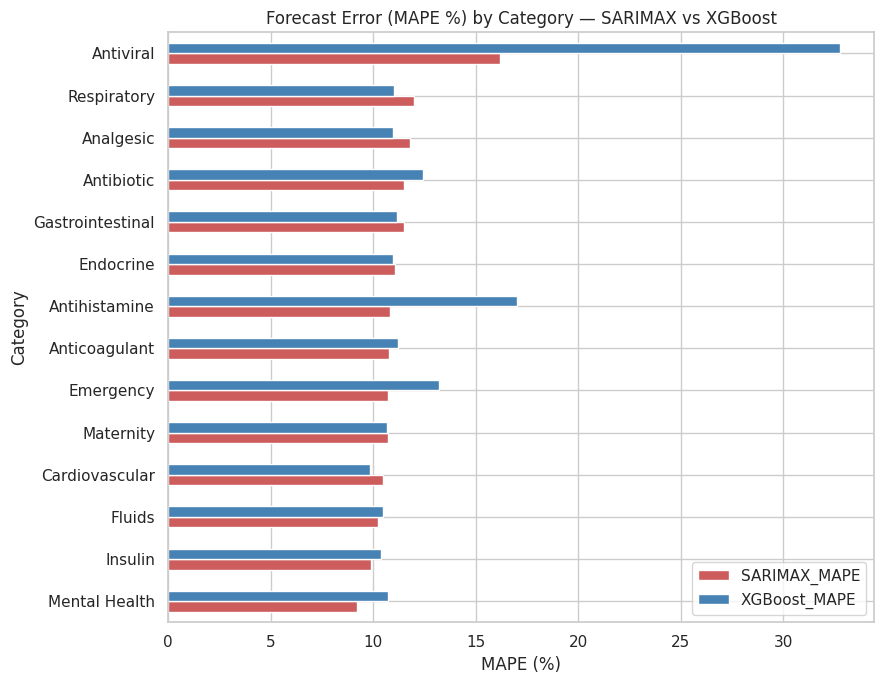

In [55]:
# %%
# ---- CELL 6: Visual — side-by-side MAPE per category ----
plot_df = cat_comparison[["SARIMAX_MAPE", "XGBoost_MAPE"]].sort_values("SARIMAX_MAPE")
plot_df.plot(kind="barh", figsize=(9, 7), color=["indianred", "steelblue"])
plt.title("Forecast Error (MAPE %) by Category — SARIMAX vs XGBoost")
plt.xlabel("MAPE (%)")
plt.tight_layout()
plt.show()

# **Decide the "best model per category" mapping**

In [57]:
# %%
# ---- CELL 7: Decide the "best model per category" mapping ----
# This becomes your production rule: use whichever model performs better for each
# category going forward, rather than picking one model Trust-wide.
best_model_lookup = cat_comparison["Better_Model"].to_dict()
print(best_model_lookup)

# Build a single "Final_Forecast" column using this rule for the replenishment ledger
comparison_cat["Final_Forecast"] = np.where(
    comparison_cat["Category"].map(best_model_lookup) == "XGBoost",
    comparison_cat["XGBoost_Forecast"],
    comparison_cat["SARIMAX_Forecast"]
)

comparison_cat.to_csv("final_forecasts.csv", index=False)
comparison_cat.head()

{'Analgesic': 'XGBoost', 'Antibiotic': 'SARIMAX', 'Anticoagulant': 'SARIMAX', 'Antihistamine': 'SARIMAX', 'Antiviral': 'SARIMAX', 'Cardiovascular': 'XGBoost', 'Emergency': 'SARIMAX', 'Endocrine': 'XGBoost', 'Fluids': 'SARIMAX', 'Gastrointestinal': 'XGBoost', 'Insulin': 'SARIMAX', 'Maternity': 'XGBoost', 'Mental Health': 'SARIMAX', 'Respiratory': 'XGBoost'}


,Hospital_ID,Medicine_ID,Date,Actual_Demand,SARIMAX_Forecast,XGBoost_Forecast,Category,Final_Forecast
0,H01,M001,2025-01-01,3075,2389.104311,2279.6523,Antibiotic,2389.104311
1,H01,M001,2025-02-01,2257,2219.880834,2550.3850,Antibiotic,2219.880834
2,H01,M001,2025-03-01,1822,2290.574310,2170.4875,Antibiotic,2290.574310
3,H01,M001,2025-04-01,1437,1460.206578,1398.7389,Antibiotic,1460.206578
4,H01,M001,2025-05-01,1231,1554.660294,1286.4913,Antibiotic,1554.660294


# **Overall improvement headline for the stakeholder deck**

In [58]:
# %%
# ---- CELL 8: Overall improvement headline for the stakeholder deck ----
overall_sarimax_mape = metrics(comparison["Actual_Demand"], comparison["SARIMAX_Forecast"])["MAPE"]
overall_final_mape = np.mean(
    np.abs((comparison_cat["Actual_Demand"] - comparison_cat["Final_Forecast"])
           / comparison_cat["Actual_Demand"].replace(0, np.nan))
) * 100

print(f"SARIMAX-only MAPE: {overall_sarimax_mape:.1f}%")
print(f"Best-of-both (per-category) MAPE: {overall_final_mape:.1f}%")
print(f"Improvement vs SARIMAX baseline: "
      f"{(overall_sarimax_mape - overall_final_mape) / overall_sarimax_mape * 100:.1f}%")

SARIMAX-only MAPE: 11.2%
Best-of-both (per-category) MAPE: 10.9%
Improvement vs SARIMAX baseline: 2.7%


# **END OF NOTEBOOK 4**

---



# **Inventory / Replenishment Ledger (FR-3.1 - FR-3.7)**

# **Setup & Imports**

In [59]:
# %%
# ---- CELL 1: Setup & Imports ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# %%
# ---- CELL 2: Load final forecasts + supporting reference data ----
from google.colab import files
uploaded = files.upload()
# select: final_forecasts.csv, panel_master.csv, Medicine.csv, Hospital.csv

final_forecasts = pd.read_csv("final_forecasts.csv", parse_dates=["Date"])
panel = pd.read_csv("panel_master.csv", parse_dates=["Date"])
medicine = pd.read_csv("Medicine.csv")
hospital = pd.read_csv("Hospital.csv")

Saving final_forecasts.csv to final_forecasts (1).csv


# **Pull in Current_Stock and Unit_Cost as of each forecasted month**

In [60]:
# %%
# ---- CELL 3: Pull in Current_Stock and Unit_Cost as of each forecasted month ----
# (final_forecasts.csv only carries Actual/Forecast demand — bring stock & cost back in)
ledger = final_forecasts.merge(
    panel[["Hospital_ID", "Medicine_ID", "Date", "Current_Stock", "Unit_Cost"]],
    on=["Hospital_ID", "Medicine_ID", "Date"],
    how="left"
)
ledger = ledger.merge(
    medicine[["Medicine_ID", "Medicine_Name", "Shelf_Life_Months"]],
    on="Medicine_ID", how="left"
)
ledger.head()

,Hospital_ID,Medicine_ID,Date,Actual_Demand,SARIMAX_Forecast,XGBoost_Forecast,Category,Final_Forecast,Current_Stock,Unit_Cost,Medicine_Name,Shelf_Life_Months
0,H01,M001,2025-01-01,3075,2389.104311,2279.6523,Antibiotic,2389.104311,187,0.1747,Amoxicillin 500mg,24
1,H01,M001,2025-02-01,2257,2219.880834,2550.3850,Antibiotic,2219.880834,2999,0.1637,Amoxicillin 500mg,24
2,H01,M001,2025-03-01,1822,2290.574310,2170.4875,Antibiotic,2290.574310,1177,0.1707,Amoxicillin 500mg,24
3,H01,M001,2025-04-01,1437,1460.206578,1398.7389,Antibiotic,1460.206578,1843,0.1572,Amoxicillin 500mg,24
4,H01,M001,2025-05-01,1231,1554.660294,1286.4913,Antibiotic,1554.660294,612,0.1657,Amoxicillin 500mg,24


# **Safety stock assumption (FR-3.1)**

In [62]:
# %%
# ---- CELL 4: Safety stock assumption (FR-3.1) ----
# NOTE: this % is a starting assumption per BRD Section 10 — flag to stakeholders
# that clinical/operational sign-off is needed, and consider presenting a few
# scenarios (see Cell 8) rather than a single fixed number.
SAFETY_STOCK_PCT = 0.20  # 20% buffer over forecasted demand — placeholder assumption

ledger["Safety_Stock"] = ledger["Final_Forecast"] * SAFETY_STOCK_PCT

# **Core replenishment formulas (FR-3.2 - FR-3.5)**

In [63]:
# %%
# ---- CELL 5: Core replenishment formulas (FR-3.2 - FR-3.5) ----
ledger["Target_Stock"] = ledger["Final_Forecast"] + ledger["Safety_Stock"]
ledger["Projected_Stock"] = ledger["Current_Stock"] - ledger["Final_Forecast"]
ledger["Replenishment_Qty"] = (ledger["Target_Stock"] - ledger["Projected_Stock"]).clip(lower=0)
ledger["Replenishment_Cost"] = ledger["Replenishment_Qty"] * ledger["Unit_Cost"]

# **Build the final ledger table with exact BRD columns (FR-3.6)**

In [64]:
# %%
# ---- CELL 6: Build the final ledger table with exact BRD columns (FR-3.6) ----
replenishment_ledger = ledger[[
    "Hospital_ID", "Medicine_ID", "Medicine_Name", "Date",
    "Actual_Demand", "Final_Forecast", "Current_Stock", "Projected_Stock",
    "Replenishment_Qty", "Replenishment_Cost", "Shelf_Life_Months"
]].rename(columns={"Final_Forecast": "Forecast_Demand"})

replenishment_ledger = replenishment_ledger.merge(
    hospital[["Hospital_ID", "Hospital_Name"]], on="Hospital_ID", how="left"
)

replenishment_ledger.to_csv("replenishment_ledger.csv", index=False)
replenishment_ledger.head(10)

,Hospital_ID,Medicine_ID,Medicine_Name,Date,Actual_Demand,Forecast_Demand,Current_Stock,Projected_Stock,Replenishment_Qty,Replenishment_Cost,Shelf_Life_Months,Hospital_Name
0,H01,M001,Amoxicillin 500mg,2025-01-01,3075,2389.104311,187,-2202.104311,5069.029485,885.559451,24,Northbridge General Hospital
1,H01,M001,Amoxicillin 500mg,2025-02-01,2257,2219.880834,2999,779.119166,1884.737834,308.531583,24,Northbridge General Hospital
2,H01,M001,Amoxicillin 500mg,2025-03-01,1822,2290.574310,1177,-1113.574310,3862.263481,659.288376,24,Northbridge General Hospital
3,H01,M001,Amoxicillin 500mg,2025-04-01,1437,1460.206578,1843,382.793422,1369.454472,215.278243,24,Northbridge General Hospital
4,H01,M001,Amoxicillin 500mg,2025-05-01,1231,1554.660294,612,-942.660294,2808.252647,465.327464,24,Northbridge General Hospital
5,H01,M001,Amoxicillin 500mg,2025-06-01,1030,987.651987,1029,41.348013,1143.834372,198.912797,24,Northbridge General Hospital
6,H01,M001,Amoxicillin 500mg,2025-07-01,925,865.971354,104,-761.971354,1801.136979,290.703508,24,Northbridge General Hospital
7,H01,M001,Amoxicillin 500mg,2025-08-01,922,1122.092684,853,-269.092684,1615.603904,276.106707,24,Northbridge General Hospital
8,H01,M001,Amoxicillin 500mg,2025-09-01,1529,1110.235252,37,-1073.235252,2405.517554,418.800606,24,Northbridge General Hospital
9,H01,M001,Amoxicillin 500mg,2025-10-01,1498,1467.464210,1469,1.535790,1759.421262,291.008277,24,Northbridge General Hospital


# **Summary totals for stakeholders (FR-3.7)**

In [65]:
# %%
# ---- CELL 7: Summary totals for stakeholders (FR-3.7) ----
latest_month = replenishment_ledger["Date"].max()
latest_ledger = replenishment_ledger[replenishment_ledger["Date"] == latest_month]

total_replenishment_cost = latest_ledger["Replenishment_Cost"].sum()
n_needing_replenishment = (latest_ledger["Replenishment_Qty"] > 0).sum()

print(f"Latest month: {latest_month.date()}")
print(f"Total replenishment cost recommended: £{total_replenishment_cost:,.0f}")
print(f"Medicines needing replenishment: {n_needing_replenishment} "
      f"of {len(latest_ledger)} hospital-medicine combinations")

Latest month: 2025-12-01
Total replenishment cost recommended: £897,718
Medicines needing replenishment: 360 of 360 hospital-medicine combinations


# **Safety-stock scenario comparison (for stakeholder discussion)**

In [66]:
# %%
# ---- CELL 8: Safety-stock scenario comparison (for stakeholder discussion) ----
# Since SAFETY_STOCK_PCT is an assumption, show how sensitive total cost is to it —
# gives Pharmacy leadership something concrete to weigh in on.
scenarios = [0.10, 0.20, 0.30]
scenario_results = []

for pct in scenarios:
    safety = latest_ledger["Final_Forecast"] * pct if "Final_Forecast" in latest_ledger else \
             latest_ledger["Forecast_Demand"] * pct
    target = latest_ledger["Forecast_Demand"] + safety
    projected = latest_ledger["Current_Stock"] - latest_ledger["Forecast_Demand"]
    replen_qty = (target - projected).clip(lower=0)
    replen_cost = (replen_qty * (latest_ledger["Replenishment_Cost"] /
                                  latest_ledger["Replenishment_Qty"].replace(0, np.nan))).fillna(0)
    scenario_results.append({
        "Safety_Stock_%": f"{int(pct*100)}%",
        "Total_Replenishment_Cost": replen_cost.sum(),
        "Medicines_Needing_Replenishment": (replen_qty > 0).sum()
    })

scenario_df = pd.DataFrame(scenario_results)
print(scenario_df)

  Safety_Stock_%  Total_Replenishment_Cost  Medicines_Needing_Replenishment
0            10%             850285.690217                              360
1            20%             897718.257199                              360
2            30%             945150.824181                              360


# **Flag urgent/high-priority items (feeds dashboard FR-4.3)**

In [67]:
# %%
# ---- CELL 9: Flag urgent/high-priority items (feeds dashboard FR-4.3) ----
# Priority flag: high replenishment need relative to target stock, or stock
# already at/near zero for the latest month
latest_ledger = latest_ledger.copy()
latest_ledger["Priority"] = np.select(
    [
        latest_ledger["Current_Stock"] <= 0,
        latest_ledger["Replenishment_Qty"] > latest_ledger["Forecast_Demand"] * 0.5,
    ],
    ["Urgent", "High"],
    default="Normal"
)

print(latest_ledger["Priority"].value_counts())
latest_ledger.to_csv("latest_month_ledger_with_priority.csv", index=False)

Priority
High      357
Urgent      3
Name: count, dtype: int64


# **Visual — top 15 medicines by recommended replenishment cost**

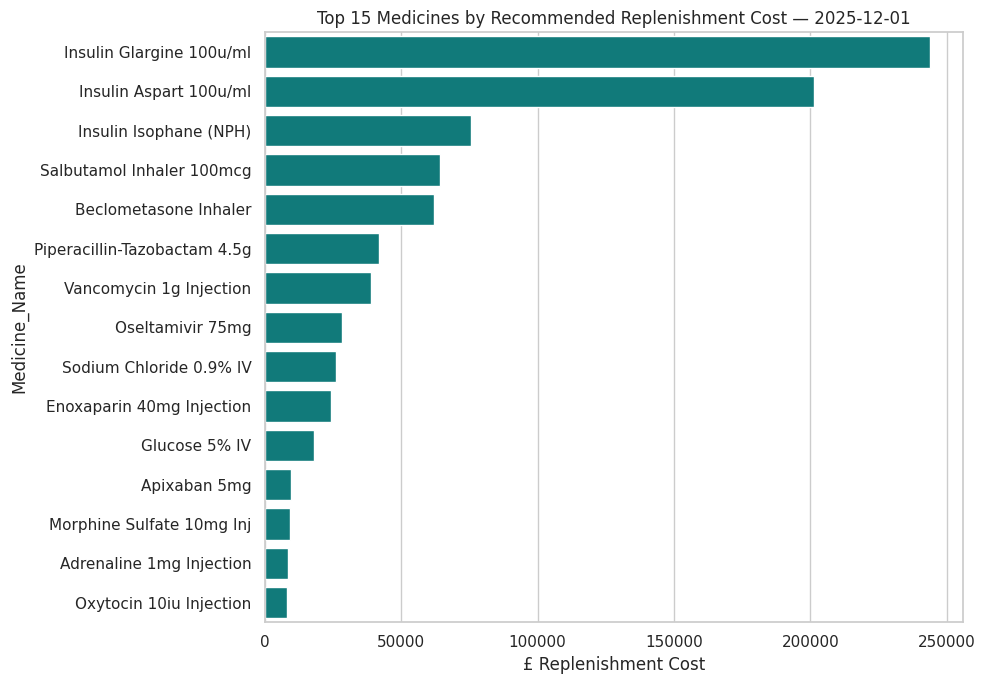

In [68]:
# %%
# ---- CELL 10: Visual — top 15 medicines by recommended replenishment cost ----
top15 = latest_ledger.groupby("Medicine_Name")["Replenishment_Cost"].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(x=top15.values, y=top15.index, color="darkcyan")
plt.title(f"Top 15 Medicines by Recommended Replenishment Cost — {latest_month.date()}")
plt.xlabel("£ Replenishment Cost")
plt.tight_layout()
plt.show()

# **Priority breakdown by hospital**

Priority                             High  Urgent
Hospital_Name                                    
Ashfield Community Hospital            44       1
Millbrook Community Hospital           45       0
Northbridge Cardiac & Stroke Centre    45       0
Northbridge Children's Hospital        45       0
Northbridge General Hospital           45       0
Northbridge Maternity Hospital         44       1
Northbridge Royal Infirmary            44       1
Riverside General Hospital             45       0


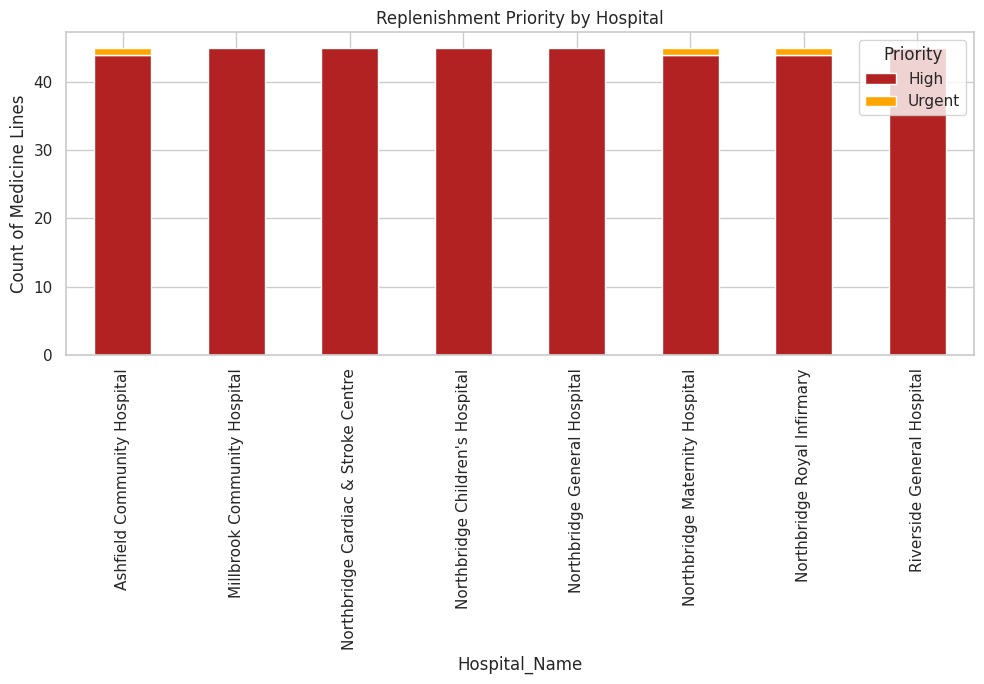

In [71]:
# %%
# ---- CELL 11: Priority breakdown by hospital ----
priority_by_hospital = latest_ledger.groupby(["Hospital_Name", "Priority"]).size().unstack(fill_value=0)
print(priority_by_hospital)

priority_by_hospital.plot(kind="bar", stacked=True, figsize=(10, 7),
                            color=["firebrick", "orange", "lightgrey"])
plt.title("Replenishment Priority by Hospital")
plt.ylabel("Count of Medicine Lines")
plt.tight_layout()
plt.show()

# **END OF NOTEBOOK 5**

---



# **Interactive Dashboard (Streamlit)**

In [95]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

st.set_page_config(
    page_title="Northbridge Medicine Demand Dashboard",
    layout="wide",
)

# -----------------------------------------------------------------------
# DATA LOADING
# -----------------------------------------------------------------------
@st.cache_data
def load_data():
    ledger = pd.read_csv("replenishment_ledger.csv", parse_dates=["Date"])
    latest_ledger = pd.read_csv("latest_month_ledger_with_priority.csv", parse_dates=["Date"])
    forecasts = pd.read_csv("final_forecasts.csv", parse_dates=["Date"])
    medicine = pd.read_csv("Medicine.csv")
    hospital = pd.read_csv("Hospital.csv")
    return ledger, latest_ledger, forecasts, medicine, hospital

ledger, latest_ledger, forecasts, medicine, hospital = load_data()

# -----------------------------------------------------------------------
# SIDEBAR FILTERS (FR-4.2)
# -----------------------------------------------------------------------
st.sidebar.title("Filters")

hospital_options = ["All Hospitals"] + sorted(hospital["Hospital_Name"].unique().tolist())
selected_hospital = st.sidebar.selectbox("Hospital", hospital_options)

medicine_options = ["All Medicines"] + sorted(medicine["Medicine_Name"].unique().tolist())
selected_medicine = st.sidebar.selectbox("Medicine", medicine_options)

category_options = ["All Categories"] + sorted(medicine["Category"].unique().tolist())
selected_category = st.sidebar.selectbox("Medicine Category", category_options)

st.sidebar.markdown("---")
st.sidebar.caption("Data covers Jan 2021 - Dec 2025. Forecast/ledger view reflects "
                    "the most recent 12-month test period. Intended for monthly refresh (FR-4.4).")

# Apply filters to the ledger views used across tabs
def apply_filters(df):
    out = df.copy()
    if selected_hospital != "All Hospitals":
        out = out[out["Hospital_Name"] == selected_hospital]
    if selected_medicine != "All Medicines":
        out = out[out["Medicine_Name"] == selected_medicine]
    if selected_category != "All Categories" and "Category" in out.columns:
        out = out[out["Category"] == selected_category]
    return out

filtered_ledger = apply_filters(ledger)
filtered_latest = apply_filters(latest_ledger)

# -----------------------------------------------------------------------
# HEADER
# -----------------------------------------------------------------------
st.title("💊 Medicine Demand Forecasting & Inventory Dashboard")
st.caption("Pharmacy & Medicines Management — Analytics Team")

tab1, tab2, tab3, tab4 = st.tabs([
    "📊 Overview", "🔍 Medicine Drill-down", "⚖️ Model Comparison", "🚨 Risk Table"
])

# -----------------------------------------------------------------------
# TAB 1 — OVERVIEW (FR-4.1)
# -----------------------------------------------------------------------
with tab1:
    st.subheader("Key Metrics — Latest Month")

    n_medicines = filtered_latest["Medicine_Name"].nunique() if "Medicine_Name" in filtered_latest.columns else medicine["Medicine_Name"].nunique()
    n_at_risk = (filtered_latest["Priority"].isin(["Urgent", "High"])).sum() if len(filtered_latest) else 0
    total_replen_cost = filtered_latest["Replenishment_Cost"].sum() if len(filtered_latest) else 0
    n_urgent = (filtered_latest["Priority"] == "Urgent").sum() if len(filtered_latest) else 0

    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Medicines Tracked", n_medicines)
    col2.metric("At-Risk Items (Urgent + High)", n_at_risk)
    col3.metric("Urgent Items", n_urgent)
    col4.metric("Recommended Replenishment Cost", f"£{total_replen_cost:,.0f}")

    st.markdown("---")

    col_left, col_right = st.columns(2)

    with col_left:
        st.markdown("**Priority Breakdown**")
        if len(filtered_latest):
            priority_counts = filtered_latest["Priority"].value_counts().reset_index()
            priority_counts.columns = ["Priority", "Count"]
            fig = px.pie(priority_counts, names="Priority", values="Count",
                         color="Priority",
                         color_discrete_map={"Urgent": "#d62728", "High": "#ff7f0e", "Normal": "#2ca02c"})
            st.plotly_chart(fig, use_container_width=True)
        else:
            st.info("No data for the selected filters.")

    with col_right:
        st.markdown("**Top 10 Medicines by Replenishment Cost**")
        if len(filtered_latest):
            top10 = (filtered_latest.groupby("Medicine_Name")["Replenishment_Cost"]
                      .sum().sort_values(ascending=False).head(10).reset_index())
            fig = px.bar(top10, x="Replenishment_Cost", y="Medicine_Name", orientation="h")
            fig.update_layout(yaxis={"categoryorder": "total ascending"})
            st.plotly_chart(fig, use_container_width=True)
        else:
            st.info("No data for the selected filters.")

    st.markdown("**Trust-wide Demand Trend**")
    trend = filtered_ledger.groupby("Date")["Actual_Demand"].sum().reset_index()
    fig = px.line(trend, x="Date", y="Actual_Demand", markers=True)
    st.plotly_chart(fig, use_container_width=True)

# -----------------------------------------------------------------------
# TAB 2 — MEDICINE DRILL-DOWN
# -----------------------------------------------------------------------
with tab2:
    st.subheader("Forecast vs Actual — Selected Medicine")

    if selected_medicine == "All Medicines":
        st.info("Select a specific medicine from the sidebar to see its forecast detail.")
    else:
        drill = filtered_ledger.sort_values("Date")
        if selected_hospital == "All Hospitals":
            drill = drill.groupby("Date").agg(
                Actual_Demand=("Actual_Demand", "sum"),
                Forecast_Demand=("Forecast_Demand", "sum"),
                Current_Stock=("Current_Stock", "sum"),
                Replenishment_Qty=("Replenishment_Qty", "sum"),
            ).reset_index()

        fig = go.Figure()
        fig.add_trace(go.Scatter(x=drill["Date"], y=drill["Actual_Demand"],
                                  name="Actual Demand", mode="lines+markers"))
        fig.add_trace(go.Scatter(x=drill["Date"], y=drill["Forecast_Demand"],
                                  name="Forecast Demand", mode="lines+markers"))
        fig.update_layout(title=f"{selected_medicine} — Actual vs Forecast", height=450)
        st.plotly_chart(fig, use_container_width=True)

        col1, col2 = st.columns(2)
        with col1:
            st.markdown("**Current Stock Over Time**")
            fig2 = px.line(drill, x="Date", y="Current_Stock", markers=True)
            st.plotly_chart(fig2, use_container_width=True)
        with col2:
            st.markdown("**Recommended Replenishment Quantity Over Time**")
            fig3 = px.bar(drill, x="Date", y="Replenishment_Qty")
            st.plotly_chart(fig3, use_container_width=True)

        latest_row = drill[drill["Date"] == drill["Date"].max()]
        if len(latest_row):
            st.markdown("**Latest Month Snapshot**")
            r = latest_row.iloc[0]
            m1, m2, m3, m4 = st.columns(4)
            m1.metric("Forecast Demand", f"{r['Forecast_Demand']:.0f}")
            m2.metric("Current Stock", f"{r['Current_Stock']:.0f}")
            m3.metric("Recommended Order", f"{r['Replenishment_Qty']:.0f}")
            m4.metric("Replenishment Cost", f"£{filtered_latest['Replenishment_Cost'].sum():,.0f}")

# -----------------------------------------------------------------------
# TAB 3 — MODEL COMPARISON
# -----------------------------------------------------------------------
with tab3:
    st.subheader("SARIMAX vs XGBoost — Forecast Accuracy by Category")

    def mape(actual, pred):
        return np.mean(np.abs((actual - pred) / actual.replace(0, np.nan))) * 100

    cat_perf = forecasts.groupby("Category").apply(
        lambda g: pd.Series({
            "SARIMAX_MAPE": mape(g["Actual_Demand"], g["SARIMAX_Forecast"]),
            "XGBoost_MAPE": mape(g["Actual_Demand"], g["XGBoost_Forecast"]),
        })
    ).reset_index()

    cat_perf_melted = cat_perf.melt(id_vars="Category", var_name="Model", value_name="MAPE")
    fig = px.bar(cat_perf_melted, x="Category", y="MAPE", color="Model", barmode="group")
    fig.update_layout(height=450)
    st.plotly_chart(fig, use_container_width=True)

    st.markdown("**Model chosen per category (best MAPE)**")
    cat_perf["Better_Model"] = np.where(cat_perf["XGBoost_MAPE"] < cat_perf["SARIMAX_MAPE"],
                                         "XGBoost", "SARIMAX")
    st.dataframe(cat_perf.style.format({"SARIMAX_MAPE": "{:.1f}%", "XGBoost_MAPE": "{:.1f}%"}),
                 use_container_width=True)

    if selected_medicine != "All Medicines":
        st.markdown(f"**Series-level comparison — {selected_medicine}**")
        series = filtered_ledger if "SARIMAX_Forecast" in filtered_ledger.columns else None
        # Fall back to raw forecasts table filtered by medicine name via ID join
        med_id = medicine.loc[medicine["Medicine_Name"] == selected_medicine, "Medicine_ID"]
        if len(med_id):
            series = forecasts[forecasts["Medicine_ID"] == med_id.values[0]]
            if selected_hospital != "All Hospitals":
                hosp_id = hospital.loc[hospital["Hospital_Name"] == selected_hospital, "Hospital_ID"]
                if len(hosp_id):
                    series = series[series["Hospital_ID"] == hosp_id.values[0]]
            series = series.sort_values("Date")
            fig2 = go.Figure()
            fig2.add_trace(go.Scatter(x=series["Date"], y=series["Actual_Demand"], name="Actual"))
            fig2.add_trace(go.Scatter(x=series["Date"], y=series["SARIMAX_Forecast"], name="SARIMAX"))
            fig2.add_trace(go.Scatter(x=series["Date"], y=series["XGBoost_Forecast"], name="XGBoost"))
            st.plotly_chart(fig2, use_container_width=True)

# -----------------------------------------------------------------------
# TAB 4 — RISK TABLE (FR-4.3)
# -----------------------------------------------------------------------
with tab4:
    st.subheader("Replenishment Risk Table — Latest Month")

    priority_filter = st.multiselect(
        "Show priority levels", options=["Urgent", "High", "Normal"],
        default=["Urgent", "High"]
    )

    risk_view = filtered_latest[filtered_latest["Priority"].isin(priority_filter)].copy() \
        if len(filtered_latest) else filtered_latest

    display_cols = ["Hospital_Name", "Medicine_Name", "Priority", "Forecast_Demand",
                     "Current_Stock", "Projected_Stock", "Replenishment_Qty",
                     "Replenishment_Cost", "Shelf_Life_Months"]
    display_cols = [c for c in display_cols if c in risk_view.columns]

    def highlight_priority(row):
        color_map = {"Urgent": "background-color: #ffcccc",
                     "High": "background-color: #ffe5cc",
                     "Normal": ""}
        return [color_map.get(row["Priority"], "")] * len(row)

    if len(risk_view):
        st.dataframe(
            risk_view[display_cols].sort_values("Replenishment_Cost", ascending=False)
            .style.apply(highlight_priority, axis=1)
            .format({"Forecast_Demand": "{:.0f}", "Current_Stock": "{:.0f}",
                     "Projected_Stock": "{:.0f}", "Replenishment_Qty": "{:.0f}",
                     "Replenishment_Cost": "£{:,.0f}"}),
            use_container_width=True, height=500
        )
        st.download_button(
            "Download this risk table as CSV",
            risk_view[display_cols].to_csv(index=False).encode("utf-8"),
            file_name="risk_table.csv",
            mime="text/csv",
        )
    else:
        st.info("No items match the selected filters and priority levels.")

Overwriting app.py


In [96]:
!pip install streamlit pyngrok -q

In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴

⠦⠧2026-07-24 01:32:36.024 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.106.214.207:8501

your url is: https://shaky-hoops-glow.loca.lt
2026-07-24 01:36:46.230 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-07-24 01:36:46.276 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-07-24 01:36:46.310 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use

# **Importing Libraries**

# **END OF NOTEBOOK 6**

---

